In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.signal import sawtooth
import scipy.optimize
from scipy.stats import moment

In [2]:
import iminuit

In [3]:
from iminuit import minimize  # has same interface as scipy.optimize.minimize
from iminuit import Minuit, describe

# we also need a cost function to fit and import the LeastSquares function
from iminuit.cost import LeastSquares
from iminuit.cost import UnbinnedNLL

from iminuit.typing import Annotated, Gt

%config InlineBackend.figure_formats = ['svg']


print("iminuit version:", iminuit.__version__)

iminuit version: 2.30.0


In [4]:
def sinus(x, A, omega, phi0):
    y = A*np.sin(omega*x + phi0)
    return y

def saw(x, A, omega, phi0):
    y = A*sawtooth(omega*x + phi0)
    return y

def chisquare(x, y, yerr, model, A, omega, phi0):
    L = len(x)
    chi2 = 0

    for i in range(L):
        y_model = model(x[i], A, omega, phi0)
        chi2 += (y[i] - y_model)**2 / yerr[i]**2

    return chi2

In [5]:
import re

In [6]:
def extract_values(filename):
    # Regex to match the required keys and capture their numeric values
    pattern = re.compile(
        r'\btau=([+-]?\d+(?:\.\d+)?)\b|'
        r'\bamp=([+-]?\d+(?:\.\d+)?)\b|'
        r'\blc_length_years=([+-]?\d+(?:\.\d+)?)\b|'
        r'\bwindow_start(?:_day)?=([+-]?\d+(?:\.\d+)?)\b'
    )

    results = {
        'tau': None,
        'amp': None,
        'lc_length_years': None,
        'window_start': None
    }

    with open(filename, 'r', encoding='utf-8') as f:
        first_line = f.readline()
        for match in pattern.finditer(first_line):
            if match.group(1) is not None:
                results['tau'] = float(match.group(1))
            elif match.group(2) is not None:
                results['amp'] = float(match.group(2))
            elif match.group(3) is not None:
                results['lc_length_years'] = float(match.group(3))
            elif match.group(4) is not None:
                results['window_start'] = float(match.group(4))
    return results


Over 1000 files

In [8]:
ic_omega=0.01

In [9]:
chi2_sin = []
chi2_saw = []

par_sin = []
par_saw = []

for i in range(0,1000):
    
    file = 'lc_%04d.txt' % i
        
    data = pd.read_csv(file, sep="\s+", header=None, skiprows=2)
    data.columns = ['time','flux','flux_err']

    least_squares = LeastSquares(data['time'],data['flux'],data['flux_err'], sinus)
    
    m = Minuit(least_squares, A=1, omega=ic_omega, phi0=0)  # starting values for α and β
    m.limits['A'] = (1e-4,(max(data['flux'])-min(data['flux']))/2)
    m.limits['omega'] = (np.pi/(max(data['time'])-min(data['time'])), 2*np.pi*3)
    
    m.migrad()  # finds minimum of least_squares function
    m.hesse()

    par_sin = np.append(par_sin, m.values)
    chi2_sin = np.append(chi2_sin, m.fval/(len(data['time'])-m.nfit))
    
    least_squares2 = LeastSquares(data['time'],data['flux'],data['flux_err'], saw)
    
    m2 = Minuit(least_squares2, A=1, omega=ic_omega, phi0=0)  # starting values for α and β
    m2.limits['A'] = (1e-4,(max(data['flux'])-min(data['flux']))/2)
    m2.limits['omega'] = (np.pi/(max(data['time'])-min(data['time'])), 2*np.pi*3)
    
    m2.migrad()  # finds minimum of least_squares function
    m2.hesse()

    par_saw = np.append(par_saw, m2.values)
    chi2_saw = np.append(chi2_saw,m2.fval/(len(data['time'])-m2.nfit))

In [10]:
chi2_sin.sum()

141662.12161583567

In [11]:
chi2_saw.sum()

148352.92729528094

In [12]:
par_sin = np.array(par_sin)
par_saw = np.array(par_saw)

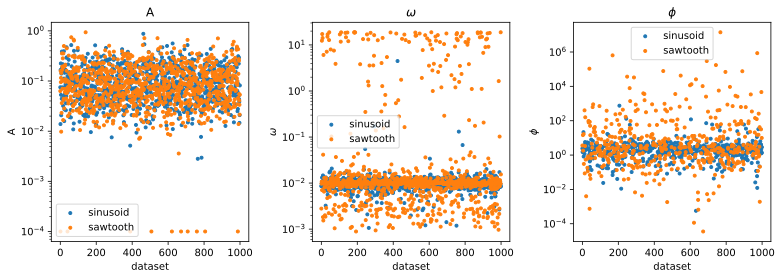

In [13]:
fig, ax = plt.subplots(1,3, figsize=(11,4))
x = range(0,1000)

for i, name in zip(range(3), ['A',r'$\omega$',r'$\phi$']):
    ax[i].scatter(x,par_sin[i::3],label='sinusoid',marker='.')
    ax[i].scatter(x,par_saw[i::3],label='sawtooth',marker='.')
    ax[i].set_title(name)
    ax[i].set_yscale('log')
    ax[i].set_ylabel(name)
    ax[i].set_xlabel('dataset')
    ax[i].legend()
plt.tight_layout()


In [14]:
np.mean(chi2_saw-chi2_sin)

6.6908056794452655

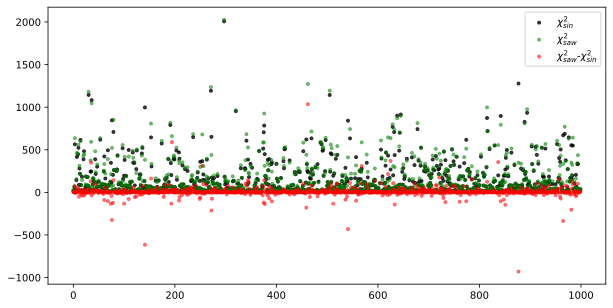

In [15]:
plt.subplots(figsize=(10,5))


x = np.arange(0,len(chi2_sin))
plt.scatter(x,chi2_sin,marker='.',color='k',alpha=0.75,label=r'$\chi^2_{sin}$')
plt.scatter(x,chi2_saw,marker='.',color='g',alpha=0.5,label=r'$\chi^2_{saw}$')
plt.scatter(x,chi2_saw-chi2_sin,marker='.',color='r',alpha=0.5,label=r'$\chi^2_{saw}$-$\chi^2_{sin}$')
plt.legend()

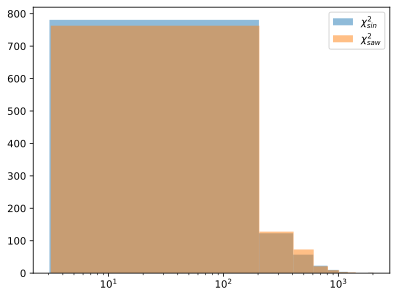

In [16]:
bins = np.logspace(0,3,30)
plt.hist(chi2_sin,bins=10,alpha=0.5,label=r'$\chi^2_{sin}$')
plt.hist(chi2_saw,bins=10,alpha=0.5,label=r'$\chi^2_{saw}$')
plt.legend()
plt.xscale('log')

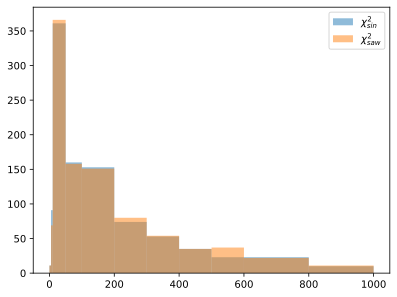

In [17]:
plt.hist(chi2_sin,bins=[0,5,10,50,100,200,300,400,500,600,800,1000],alpha=0.5,label=r'$\chi^2_{sin}$')
plt.hist(chi2_saw,bins=[0,5,10,50,100,200,300,400,500,600,800,1000],alpha=0.5,label=r'$\chi^2_{saw}$')
plt.legend()

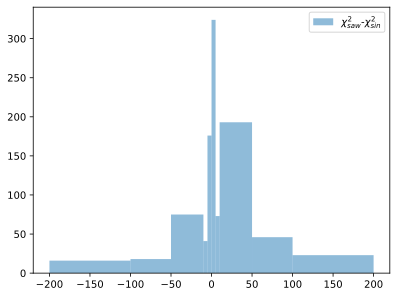

In [18]:
plt.hist(chi2_saw-chi2_sin,bins=[-200,-100,-50,-10,-5,0,5,10,50,100,200],alpha=0.5,label=r'$\chi^2_{saw}$-$\chi^2_{sin}$')
plt.legend()

In [19]:
mean = np.mean(chi2_saw-chi2_sin)
mean

6.6908056794452655

[]

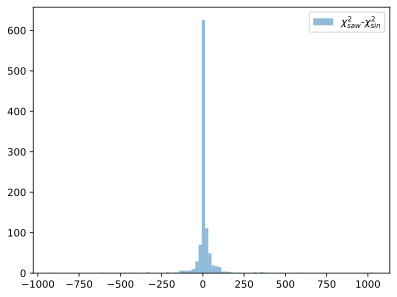

In [20]:
plt.hist(chi2_saw-chi2_sin,100,alpha=0.5,label=r'$\chi^2_{saw}$-$\chi^2_{sin}$')
plt.legend()
plt.plot()
#plt.xlim(-100,150)

In [21]:
sin_counter = 0
saw_counter = 0
for i in range(len(chi2_sin)):
    if chi2_sin[i]<chi2_saw[i]: sin_counter+=1
    else: saw_counter+=1

print('sinusoidal function is a better descriptor in %d / %d of cases' % (sin_counter, len(chi2_sin)))
print('sawtooth function is a better descriptor in %d / %d of cases' % (saw_counter, len(chi2_sin)))

sinusoidal function is a better descriptor in 667 / 1000 of cases
sawtooth function is a better descriptor in 333 / 1000 of cases


In [22]:
np.mean(chi2_saw-chi2_sin),np.var(chi2_saw-chi2_sin),scipy.stats.skew(chi2_saw-chi2_sin),scipy.stats.kurtosis(chi2_saw-chi2_sin)

(6.6908056794452655, 4877.587101826187, 0.7116683821582437, 93.42202391754621)